In [3]:
import torch
from torch.utils.data import DataLoader, TensorDataset
from torchvision.datasets import CIFAR10, CIFAR100, MNIST, STL10
import torchvision.transforms as T
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mhnlib.utils as mhn_utils
from math import log, sqrt
import seaborn as sns
from tqdm.auto import tqdm
from pathlib import Path
import re
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
#device = torch.device("cpu")

### Preparation

In [4]:
torch.manual_seed(1101252)
IMG_SIZE = 64
DATASET = "mnist"  # cifar10, cifar100, stl10, mnist

tfm = T.Compose([
    T.Resize(IMG_SIZE, interpolation=T.InterpolationMode.BICUBIC),
    T.CenterCrop(IMG_SIZE),
    T.Grayscale(num_output_channels=3),
    T.ToTensor(),
])

if DATASET == "cifar100":
    dataset = CIFAR100(root="datasets/cifar100/", train=True, download=True, transform=tfm)
    test_set = CIFAR100(root="datasets/cifar100/", train=False, download=True, transform=tfm)
if DATASET == "cifar10":
    dataset = CIFAR10(root="datasets/cifar10/", train=True, download=True, transform=tfm)
    test_set = CIFAR10(root="datasets/cifar10/", train=False, download=True, transform=tfm)
elif DATASET == "stl10":
    dataset = STL10(root="datasets/stl10/", split="train", download=True, transform=tfm)
    test_set = STL10(root="datasets/stl10/", split="test", download=True, transform=tfm)
elif DATASET == "mnist":
    dataset = MNIST(root="datasets/mnist/", train=True, download=True, transform=tfm)
    test_set = MNIST(root="datasets/mnist/", train=False, download=True, transform=tfm)
num_classes = len(dataset.classes)
print(f"Number of classes: {num_classes}")

Number of classes: 10


In [3]:
def shift_and_rms(x, eps=1e-12):
    shift = x.mean(dim=0, keepdim=True)
    x_shifted = x - shift

    rms = x_shifted.norm(dim=1).square().mean().sqrt()
    rms = rms.clamp_min(eps)

    x_norm = x_shifted / rms

    return shift, rms, x_norm
@torch.no_grad()
def decode_latents(z, z_mean, z_std, vae_model, vae_scaling, batch_size=0, verbose=False):
    orig_ndim = z.ndim

    if z.ndim == 4:
        B, C, H, W = z.shape
        vae_input = z * z_std + z_mean

    elif z.ndim == 5:
        B1, B2, C, H, W = z.shape
        vae_input = z.reshape(B1 * B2, C, H, W)
        vae_input = vae_input * z_std + z_mean

    else:
        raise ValueError("z must have 4 or 5 dimensions.")

    vae_input = vae_input / vae_scaling

    if batch_size > 0:
        vae_decoded = []

        chunks = torch.split(vae_input, batch_size, dim=0)

        for chunk in tqdm(chunks, disable=not verbose):
            chunk = chunk.to(vae_model.device)
            decoded = vae_model.decode(chunk).sample.cpu()
            vae_decoded.append(decoded)

        vae_decoded = torch.cat(vae_decoded, dim=0)

    else:
        vae_decoded = vae_model.decode(
            vae_input.to(vae_model.device)
        ).sample.cpu()

    if orig_ndim == 5:
        vae_decoded = vae_decoded.view(B1, B2, *vae_decoded.shape[1:])

    return (1 + vae_decoded.clamp(-1, 1)) / 2

### Data selection and creation

In [5]:
from diffusers import AutoencoderKL
ae_model = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse")
ae_model = ae_model.to(device).eval()
ae_model.requires_grad_(False)
ae_scaling = ae_model.config.scaling_factor

Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.
/home/schimmenti/miniconda3/lib/python3.14/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


In [6]:
from einops import rearrange
data = torch.as_tensor(dataset.data, dtype=torch.float32)
data = (data - data.min()) / (data.max() - data.min())  # Normalize to [0, 1]
if DATASET == "stl10":
    labels = torch.as_tensor(dataset.labels, dtype=torch.long)
elif DATASET == "mnist":
    data = rearrange(data, "N H W -> N 1 H W")  # Rearrange to (N, 1, H, W)
    data = data.repeat(1, 3, 1, 1)  # Repeat the single channel to create 3 channels
    labels = torch.as_tensor(dataset.targets, dtype=torch.long)
else:
    data = rearrange(data, "N H W C -> N C H W")  # Rearrange to (N, C, H, W)
    labels = torch.as_tensor(dataset.targets, dtype=torch.long)
num_classes = len(torch.unique(labels))

In [7]:
is_centered = False
is_euclidean = False
batch_size = 1000
betas = torch.logspace(-3,1, steps=1000)
overwrite_quenched = False
overwrite_annealed = False
num_iterations = 5000

In [8]:
for num_samples_per_class in [1, 2, 5]:
    # first seed for reproducibility
    torch.manual_seed(1101252)
    
    data_indices = []
    for c in range(num_classes):
        class_indices = torch.where(labels == c)[0]
        selected_indices = class_indices[torch.randperm(len(class_indices))[:num_samples_per_class]]
        data_indices.append(selected_indices)
    data_indices = torch.cat(data_indices)
    
    image_patterns = data[data_indices]
    with torch.no_grad():
        latents = (ae_model.encode((image_patterns).to(device)).latent_dist.mode()).cpu()
        latents = latents * ae_scaling
    C_latents, H_latents, W_latents = latents.shape[1:]

    patterns = latents.reshape(len(data_indices), -1)
    if is_centered:
        patterns = patterns - patterns.mean(dim=0, keepdim=True)
        rms = patterns.norm(dim=1, keepdim=True).mean()
        patterns /= rms
    gram = patterns @ patterns.T

    if is_euclidean:
        biases = -0.5 * torch.diagonal(gram)
    else:
        biases = torch.zeros(len(data_indices))

    # reseed for reproducibility
    torch.manual_seed(1101252)
    num_ics = 10*len(data_indices)
    w_ics = torch.zeros(num_ics, len(data_indices))
    w_ics[torch.arange(num_ics), torch.randint(0, len(data_indices), (num_ics,), dtype=torch.long)] = 1.0

    for logit_noise_std in [0.0, 0.1, 1.0, 10.0, 50.0, 100.0]:
        annealed_filename = f"paper_results/real_data/{DATASET}_w_annealed_is_centered={is_centered}_is_euclidean={is_euclidean}_per_class={num_samples_per_class}_noise={logit_noise_std:.2f}.pt"
        quenched_filename = f"paper_results/real_data/{DATASET}_w_quenched_is_centered={is_centered}_is_euclidean={is_euclidean}_per_class={num_samples_per_class}.pt"
        
        if overwrite_quenched:
            w_quenched = []
        else:
            try:
                w_quenched_data = torch.load(quenched_filename)
                w_quenched = w_quenched_data['weights']
            except:
                overwrite_quenched = True
                w_quenched = []
        if overwrite_annealed:
            w_annealed = []
        else:
            try:
                w_annealed_data = torch.load(annealed_filename)
                w_annealed = w_annealed_data['weights']
            except:
                overwrite_annealed = True
                w_annealed = []
        for batch_start in range(0, num_ics, batch_size):
            torch.cuda.empty_cache()
            batch_end = min(batch_start + batch_size, num_ics)
            if overwrite_quenched:
                w_quenched_batch = mhn_utils.dual_deterministic_dynamics(gram.to(device), 
                                                                     biases.to(device), 
                                                                     betas.to(device), 
                                                                     w_ics[batch_start:batch_end].to(device), num_iterations=num_iterations, verbose=True).cpu().squeeze()
            if overwrite_annealed:
                w_annealed_batch = mhn_utils.dual_deterministic_dynamics_annealing(gram.to(device), 
                                                             biases.to(device), 
                                                             betas.to(device), 
                                                             w_ics[batch_start:batch_end].to(device),logit_noise_std=logit_noise_std, num_iterations=num_iterations, verbose=True).cpu().squeeze()
            if overwrite_quenched:
                w_quenched.append(w_quenched_batch)
            if overwrite_annealed:
                w_annealed.append(w_annealed_batch)
        if overwrite_quenched:
            w_quenched = torch.cat(w_quenched, dim=1)
        if overwrite_annealed:
            w_annealed = torch.cat(w_annealed, dim=1)
        if overwrite_quenched:
            torch.save({'weights': w_quenched, 'indices': data_indices, 'gram' : gram, 'biases': biases, 'betas': betas}, quenched_filename)
        if overwrite_annealed:
            torch.save({'weights': w_annealed, 'indices': data_indices, 'gram' : gram, 'biases': biases, 'betas': betas}, annealed_filename)

Computing dual fixed points:   0%|          | 0/5000 [00:00<?, ?it/s]

Dual annealing:   0%|          | 0/1000 [00:00<?, ?it/s]

Computing dual fixed points:   0%|          | 0/5000 [00:00<?, ?it/s]

Dual annealing:   0%|          | 0/1000 [00:00<?, ?it/s]

Computing dual fixed points:   0%|          | 0/5000 [00:00<?, ?it/s]

...

Dual annealing:   0%|          | 0/1000 [00:00<?, ?it/s]

Computing dual fixed points:   0%|          | 0/5000 [00:00<?, ?it/s]

Dual annealing:   0%|          | 0/1000 [00:00<?, ?it/s]

Computing dual fixed points:   0%|          | 0/5000 [00:00<?, ?it/s]

Dual annealing:   0%|          | 0/1000 [00:00<?, ?it/s]

### Load

In [12]:
is_centered = False
is_euclidean = False
files = list(Path("paper_results/old_data/real_data").glob(f"{DATASET}*.pt"))
files = [f for f in files if f.is_file() and f'is_centered={is_centered}' in f.name and f'is_euclidean={is_euclidean}' in f.name]
files_df = {'type' : [], 'num_per_class': [], 'noise': [], 'filename': []}
for f in files:
    name = f.name
    num_per_class = re.search(r'per_class=(\d+)', name)
    if num_per_class:
        num_per_class = int(num_per_class.group(1))
    if 'w_annealed' in f.name:
        noise = re.search(r'noise=(\d+\.?\d*)', name)
        if noise:
            noise = float(noise.group(1))
            files_df['type'].append('annealed')
            files_df['num_per_class'].append(num_per_class)
            files_df['noise'].append(noise)
            files_df['filename'].append(str(f))
    elif 'w_quenched' in f.name:
        files_df['type'].append('quenched')
        files_df['num_per_class'].append(num_per_class)
        files_df['noise'].append(None)
        files_df['filename'].append(str(f))
files_df = pd.DataFrame.from_dict(files_df)

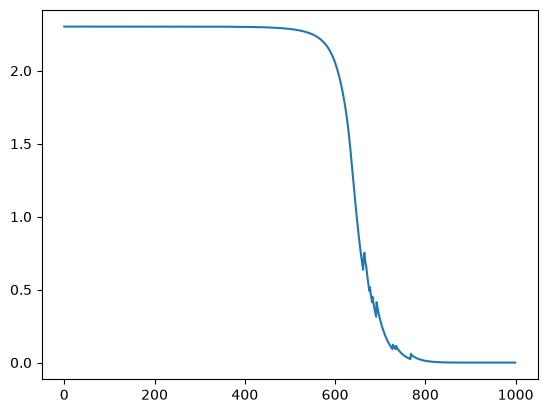

In [20]:
plt.plot(mhn_utils.get_entropy(w_quenched).mean(dim=-1))

KeyboardInterrupt: 

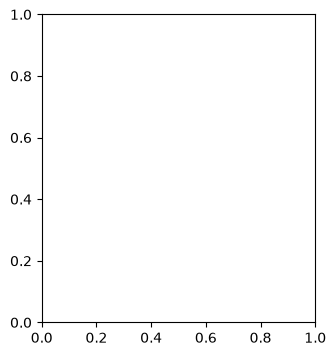

In [14]:
from sklearn.decomposition import PCA
noise_to_use = 10.0
num_betas_to_plot = -1
num_components_to_plot = 3
plots_folder = Path(f"paper_results/real_data/plots/{DATASET}/")
plots_folder.mkdir(parents=True, exist_ok=True)
for num_per_class, sub_df in files_df.groupby('num_per_class'):
    if num_per_class != 1:
        continue
    torch.cuda.empty_cache()
    quenched_df = sub_df[sub_df['type'] == 'quenched']
    annealed_df = sub_df[(sub_df['type'] == 'annealed') & (sub_df['noise'] == noise_to_use)]
    quenched_data = torch.load(quenched_df['filename'].values[0])
    annealed_data = torch.load(annealed_df['filename'].values[0])
    w_quenched = quenched_data['weights']
    w_annealed = annealed_data['weights']
    quenched_indices = quenched_data['indices']
    annealed_indices = annealed_data['indices']

    quenched_image_patterns = data[quenched_indices]
    annealed_image_patterns = data[annealed_indices]
    with torch.no_grad():
        quenched_latents = (ae_model.encode((quenched_image_patterns * ae_scaling).to(device)).latent_dist.mode()).cpu()
        annealed_latents = (ae_model.encode((annealed_image_patterns * ae_scaling).to(device)).latent_dist.mode()).cpu()
    C_latents, H_latents, W_latents = quenched_latents.shape[1:]

    quenched_patterns = quenched_latents.reshape(len(quenched_indices), -1)
    annealed_patterns = annealed_latents.reshape(len(annealed_indices), -1)
    if is_centered:
        quenched_patterns = quenched_patterns - quenched_patterns.mean(dim=0, keepdim=True)
        rms = quenched_patterns.norm(dim=1, keepdim=True).mean()
        quenched_patterns /= rms

        annealed_patterns = annealed_patterns - annealed_patterns.mean(dim=0, keepdim=True)
        rms = annealed_patterns.norm(dim=1, keepdim=True).mean()
        annealed_patterns /= rms




    for (name, patterns, weights) in ([('quenched', quenched_patterns, w_quenched), ('annealed', annealed_patterns, w_annealed)]):


        pca_model = PCA(n_components=5).fit(patterns.numpy())
        patterns_proj = torch.as_tensor(pca_model.transform(patterns.numpy()))

        plot_min_pca_vals = patterns_proj.min(dim=0, keepdim=False).values
        plot_min_pca_vals[plot_min_pca_vals < 0] *= 1.1
        plot_min_pca_vals[plot_min_pca_vals >0] *= 0.9
        plot_max_pca_vals =  patterns_proj.max(dim=0, keepdim=False).values
        plot_max_pca_vals[plot_max_pca_vals < 0] *= 0.9
        plot_max_pca_vals[plot_max_pca_vals > 0] *= 1.1

        fixed_points_proj = torch.einsum("bsk,kp->bsp", w_quenched, patterns_proj)
        
        this_plot_folder = plots_folder / f"{name}_per_class_{num_per_class}/"
        this_plot_folder.mkdir(parents=True, exist_ok=True)
        
        for i in range(num_betas_to_plot if num_betas_to_plot > 0 else fixed_points_proj.shape[0]):
            fig, axs = plt.subplots(nrows=1, ncols=num_components_to_plot*(num_components_to_plot-1)//2, figsize=(4 * num_components_to_plot*(num_components_to_plot-1)//2, 4))
            if num_betas_to_plot > 0:
                beta_idx = i * (fixed_points_proj.shape[0] // num_betas_to_plot)
            else:
                beta_idx = i
            plot_counter = 0
            for c_a in range(num_components_to_plot):
                for c_b in range(c_a + 1, num_components_to_plot):  
                    axs[plot_counter].scatter(patterns_proj[:, c_a].numpy(),
                                       patterns_proj[:, c_b].numpy(), color='blue', alpha=0.5, label='Quenched Patterns')
                    axs[plot_counter].scatter(fixed_points_proj[beta_idx, :, c_a].numpy(), 
                                      fixed_points_proj[beta_idx, :, c_b].numpy(), color='black', marker='*')
                    axs[plot_counter].set_xlim(plot_min_pca_vals[c_a].item(), plot_max_pca_vals[c_a].item())
                    axs[plot_counter].set_ylim(plot_min_pca_vals[c_b].item(), plot_max_pca_vals[c_b].item())
                    axs[plot_counter].set_aspect('equal', adjustable='box')
                    axs[plot_counter].set_xlabel(f"Component {c_a + 1}")
                    axs[plot_counter].set_ylabel(f"Component {c_b + 1}")
                    axs[plot_counter].set_title(f"Beta index: {beta_idx}")
                    plot_counter += 1
            plt.savefig(this_plot_folder / f"beta_idx_{beta_idx}.png")
            plt.close()

In [ ]:
noise_to_use = 10.0
for num_per_class, sub_df in files_df.groupby('num_per_class'):
    torch.cuda.empty_cache()
    if num_per_class != 2:
        continue

    quenched_df = sub_df[sub_df['type'] == 'quenched']
    annealed_df = sub_df[(sub_df['type'] == 'annealed') & (sub_df['noise'] == noise_to_use)]
    quenched_data = torch.load(quenched_df['filename'].values[0])
    annealed_data = torch.load(annealed_df['filename'].values[0])
    w_quenched = quenched_data['weights']
    w_annealed = annealed_data['weights']
    quenched_indices = quenched_data['indices']
    annealed_indices = annealed_data['indices']


    quenched_image_patterns = data[quenched_indices]
    annealed_image_patterns = data[annealed_indices]
    with torch.no_grad():
        quenched_latents = (ae_model.encode((quenched_image_patterns * ae_scaling).to(device)).latent_dist.mode()).cpu()
        annealed_latents = (ae_model.encode((annealed_image_patterns * ae_scaling).to(device)).latent_dist.mode()).cpu()
    C_latents, H_latents, W_latents = quenched_latents.shape[1:]

    patterns = quenched_latents.reshape(len(quenched_indices), -1)
    if is_centered:
        patterns = patterns - patterns.mean(dim=0, keepdim=True)
        rms = patterns.norm(dim=1, keepdim=True).mean()
        patterns /= rms

    latents_quenched_fixed_points = torch.einsum("bsk,kchw->bschw", w_quenched, quenched_latents)
    latents_annealed_fixed_points = torch.einsum("bsk,kchw->bschw", w_annealed, annealed_latents)
    images_quenched_fixed_points = decode_latents(latents_quenched_fixed_points, 
                                                           z_mean=quenched_latents.mean(dim=0, keepdim=True) if is_centered else 0.0,
                                                           z_std=rms if is_centered else 1.0, vae_model=ae_model, 
                                                           vae_scaling=ae_scaling, batch_size=100, verbose=True)
    images_annealed_fixed_points = decode_latents(latents_annealed_fixed_points, 
                                                               z_mean=annealed_latents.mean(dim=0, keepdim=True) if is_centered else 0.0,
                                                               z_std=rms if is_centered else 1.0, vae_model=ae_model, 
                                                               vae_scaling=ae_scaling, batch_size=100, verbose=True)
    #for ic_index in range(latents_quenched_fixed_points.shape[1]):
    #    images_quenched_fixed_points = decode_latents(latents_quenched_fixed_points[:, ic_index,...], 
    #                                                   z_mean=latents.mean(dim=0, keepdim=True) if is_centered else 0.0,
    #                                                   z_std=rms if is_centered else 1.0, vae_model=ae_model, 
    #                                                   vae_scaling=ae_scaling, batch_size=100, verbose=True)
    #    break
    
    #fig, ax = plt.subplots(figsize=(8, 6))
    #ax.plot(betas, mhn_utils.get_entropy(w_quenched).mean(dim=1), label="Quenched", color='black', linewidth=2)
    #for noise, annealed_sub_df in annealed_df.groupby('noise'):
    #    annealed_data = torch.load(annealed_sub_df['filename'].values[0])
    #    w_annealed = annealed_data['weights']
    #    entropy_annealed = mhn_utils.get_entropy(w_annealed)
    #    ax.plot(betas, entropy_annealed.mean(dim=1), label=f"Annealed (noise={noise})")
    #ax.set_xscale('log')
    #plt.show()

In [ ]:
import seaborn as sns
sns.clustermap(patterns @ patterns.T)

In [ ]:
for sample_idx in range(0,100):
    grayscale_conversion = torch.tensor([0.299, 0.587, 0.114])
    num_betas_to_plot = 20
    beta_indices_to_plot = torch.linspace(0, images_annealed_fixed_points.shape[0]-1, num_betas_to_plot).long()
    fig, axes = plt.subplots(1, num_betas_to_plot, figsize=(num_betas_to_plot * 2, 2))
    for i, beta_idx in enumerate(beta_indices_to_plot):
        image = images_quenched_fixed_points[beta_idx,sample_idx].permute(1, 2, 0)
        if DATASET == "mnist":
            image = image @ grayscale_conversion
        image = image.clamp(0, 1).numpy()
        axes[i].imshow(image)
        axes[i].axis('off')
    plt.show()